<a href="https://colab.research.google.com/github/avidada35/Customer-Churn-Prediction/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
# Task 2: Load data
from google.colab import files

print("Upload train.csv, test.csv, and sample_submission.csv")
uploaded = files.upload()

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sub = pd.read_csv('sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Upload train.csv, test.csv, and sample_submission.csv


Saving train.csv to train (1).csv
Saving test.csv to test (1).csv
Saving sample_submission.csv to sample_submission (1).csv
Train shape: (594194, 21)
Test shape: (254655, 20)


In [6]:
# Task 3: First 5 rows of train
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [7]:
# Task 4: Data types
train.dtypes

,0
id,int64
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [8]:
# Task 5: Missing value counts
train.isnull().sum()

,0
id,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
# Task 6: Target distribution
churn_pct = train['Churn'].value_counts(normalize=True) * 100
print(churn_pct)

Churn
No     77.479241
Yes    22.520759
Name: proportion, dtype: float64


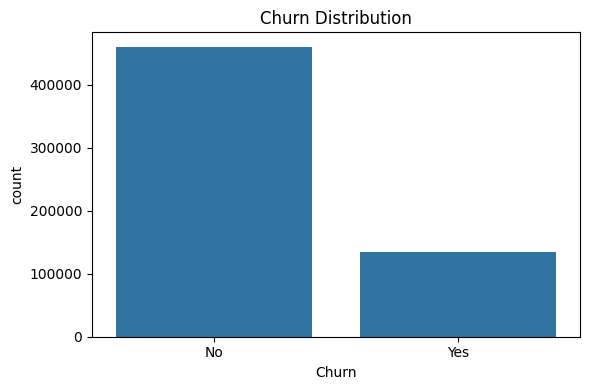

In [10]:
# Task 1: Churn distribution count plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=train)
plt.title('Churn Distribution')
plt.tight_layout()
plt.show()

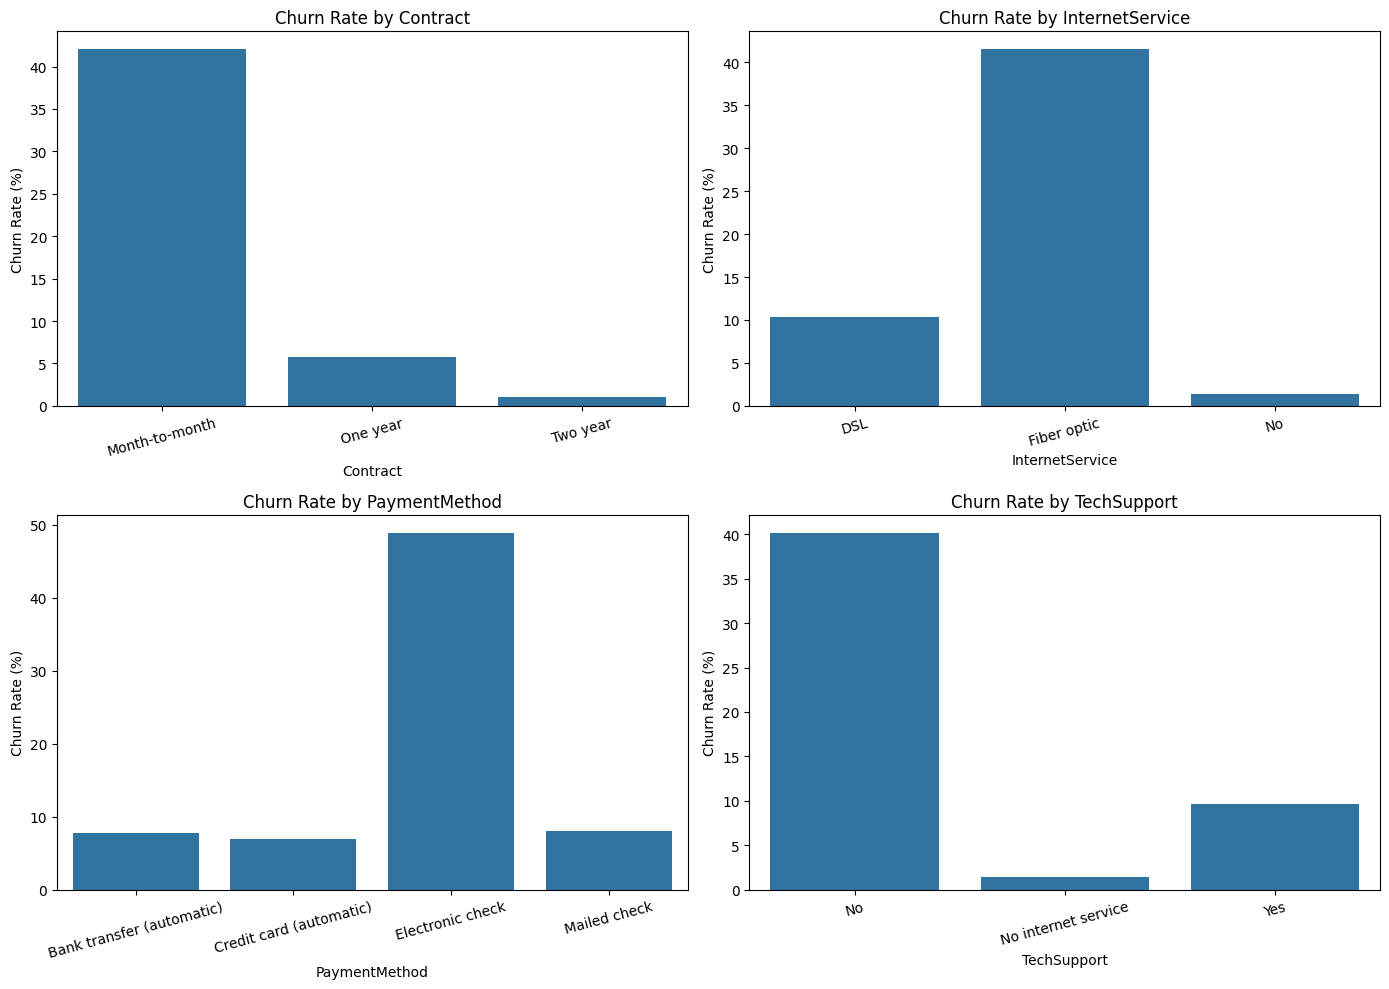

In [11]:
# Task 2: Churn rate by categorical features
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = train.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    churn_rate.columns = [col, 'ChurnRate']
    sns.barplot(x=col, y='ChurnRate', data=churn_rate, ax=axes[i])
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

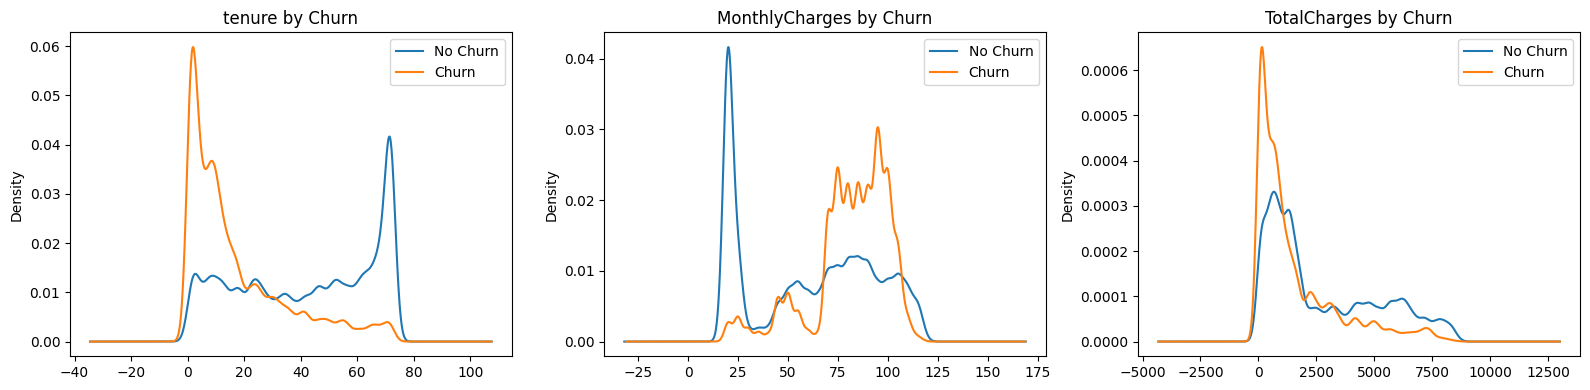

In [13]:
# Task 3: KDE plots for numeric features split by Churn
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Fix TotalCharges if it's object type
train['TotalCharges'] = pd.to_numeric(train['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(num_features):
    train[train['Churn'] == 'No'][col].dropna().plot.kde(ax=axes[i], label='No Churn')
    train[train['Churn'] == 'Yes'][col].dropna().plot.kde(ax=axes[i], label='Churn')
    axes[i].set_title(f'{col} by Churn')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [14]:
# Task 4: Average MonthlyCharges and tenure grouped by Churn
print(train.groupby('Churn')[['MonthlyCharges', 'tenure']].mean().round(2))

       MonthlyCharges  tenure
Churn                        
No              61.29   42.23
Yes             81.60   17.13


In [15]:
# Task 5: Unique values for all categorical columns
cat_cols = train.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"{col}: {train[col].unique()}")


gender: ['Male' 'Female']
Partner: ['Yes' 'No']
Dependents: ['Yes' 'No']
PhoneService: ['Yes' 'No']
MultipleLines: ['No' 'Yes' 'No phone service']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['Yes' 'No' 'No internet service']
OnlineBackup: ['No' 'Yes' 'No internet service']
DeviceProtection: ['Yes' 'No' 'No internet service']
TechSupport: ['Yes' 'No' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['One year' 'Two year' 'Month-to-month']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']
Churn: ['No' 'Yes']


In [16]:
# Task 1: Drop 'id' column
train.drop(columns=['id'], inplace=True)
test.drop(columns=['id'], inplace=True)


In [17]:
# Task 2: Convert target Churn to 1/0
train['Churn'] = (train['Churn'] == 'Yes').astype(int)
print("Churn value counts:\n", train['Churn'].value_counts())

Churn value counts:
 Churn
0    460377
1    133817
Name: count, dtype: int64


In [18]:
# Task 3: Fix TotalCharges
for df in [train, test]:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [19]:
# Task 4: Encode binary Yes/No columns to 1/0
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]

for df in [train, test]:
    for col in binary_cols:
        df[col] = (df[col] == 'Yes').astype(int)

In [20]:
# Task 5: One-hot encode remaining categorical columns
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender']

train = pd.get_dummies(train, columns=cat_cols, drop_first=True)
test  = pd.get_dummies(test,  columns=cat_cols, drop_first=True)

In [21]:
# Task 6: Align train and test columns
feature_cols = [c for c in train.columns if c != 'Churn']
test = test.reindex(columns=feature_cols, fill_value=0)

In [22]:
# Task 7: Separate features and target
X = train.drop(columns=['Churn'])
y = train['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("test shape:", test.shape)
print("\nFeature columns:\n", X.columns.tolist())

X shape: (594194, 23)
y shape: (594194,)
test shape: (254655, 23)

Feature columns:
 ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'gender_Male']


## **Model Training**

In [23]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

In [24]:
# Cross-validation function
def run_cv(model, X, y, label='Model'):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        preds = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, preds)
        auc_scores.append(auc)
        print(f"  Fold {fold} AUC: {auc:.5f}")

    print(f"\n{label} - Mean AUC: {np.mean(auc_scores):.5f} | Std: {np.std(auc_scores):.5f}")
    return auc_scores

In [25]:
# Model 1: XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

print("XGBoost CV:")
xgb_scores = run_cv(xgb_model, X, y, label='XGBoost')

XGBoost CV:
  Fold 1 AUC: 0.91539
  Fold 2 AUC: 0.91648
  Fold 3 AUC: 0.91581
  Fold 4 AUC: 0.91689
  Fold 5 AUC: 0.91415

XGBoost - Mean AUC: 0.91574 | Std: 0.00095


In [26]:
# Model 2: LightGBM
lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

print("LightGBM CV:")
lgb_scores = run_cv(lgb_model, X, y, label='LightGBM')

LightGBM CV:
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057992 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
  Fold 1 AUC: 0.91525
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057824 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if mem

In [27]:
# Compare models
xgb_mean = np.mean(xgb_scores)
lgb_mean = np.mean(lgb_scores)

print(f"\nXGBoost  Mean AUC: {xgb_mean:.5f}")
print(f"LightGBM Mean AUC: {lgb_mean:.5f}")

if lgb_mean > xgb_mean:
    print("LightGBM performs better")
else:
    print("XGBoost performs better")


XGBoost  Mean AUC: 0.91574
LightGBM Mean AUC: 0.91556
XGBoost performs better


## **Train final model on full training data**

In [28]:
# Train final model on full training data
final_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)
print("Model trained on full data")

Model trained on full data


In [29]:
# Predict probabilities on test set
test_preds = final_model.predict_proba(test)[:, 1]

print("Predictions shape:", test_preds.shape)
print("Min probability:", test_preds.min().round(5))
print("Max probability:", test_preds.max().round(5))

Predictions shape: (254655,)
Min probability: 0.00018
Max probability: 0.98659


In [32]:
# Load sample submission and replace target column
sub = pd.read_csv('sample_submission.csv')
target_col = sub.columns[-1]
sub[target_col] = test_preds

# Save submission
sub.to_csv('updated_submission.csv', index=False)
print("submission.csv saved")

submission.csv saved


In [33]:
# Verify submission format
print(pd.read_csv('submission.csv').head())

       id     Churn
0  594194  0.065479
1  594195  0.000801
2  594196  0.106849
3  594197  0.002657
4  594198  0.526991


In [34]:
import zipfile
import os
from google.colab import files

# Create a zip file with all project files
with zipfile.ZipFile('customer_churn_kaggle.zip', 'w') as zipf:

    # Add notebooks (saves current notebook)
    for f in os.listdir('/content'):
        if f.endswith('.ipynb'):
            zipf.write(f'/content/{f}', f)

    # Add CSV files
    for f in os.listdir('/content'):
        if f.endswith('.csv'):
            zipf.write(f'/content/{f}', f)

# Download the zip
files.download('customer_churn_kaggle.zip')
print("ZIP downloaded successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ZIP downloaded successfully!
